In [1]:
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

print("Movies Dataset:")
display(movies.head())

print("Ratings Dataset:")
display(ratings.head())

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

Movies Dataset:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Ratings Dataset:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Movies shape: (9742, 3)
Ratings shape: (100836, 4)


In [3]:
print("Movies Info:")
print(movies.info())

print("\nRatings Info:")
print(ratings.info())

print("\nMissing values in movies:")
print(movies.isnull().sum())

print("\nMissing values in ratings:")
print(ratings.isnull().sum())

print("\nDuplicate rows in movies:", movies.duplicated().sum())
print("Duplicate rows in ratings:", ratings.duplicated().sum())

Movies Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None

Ratings Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Duplicate rows in movies: 0
Dupl

In [4]:
# Merge ratings with movie details
movie_data = ratings.merge(movies, on="movieId")

# Convert timestamp to readable date
movie_data["timestamp"] = pd.to_datetime(movie_data["timestamp"], unit="s")

print("Merged Dataset:")
display(movie_data.head())

print("Merged shape:", movie_data.shape)

Merged Dataset:


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Merged shape: (100836, 6)


In [5]:
movie_stats = movie_data.groupby("title").agg(
    average_rating=("rating", "mean"),
    rating_count=("rating", "count")
).reset_index()

movie_stats = movie_stats.sort_values(by="rating_count", ascending=False)

display(movie_stats.head(10))

,title,average_rating,rating_count
3158,Forrest Gump (1994),4.164134,329
7593,"Shawshank Redemption, The (1994)",4.429022,317
6865,Pulp Fiction (1994),4.197068,307
7680,"Silence of the Lambs, The (1991)",4.161290,279
5512,"Matrix, The (1999)",4.192446,278
8001,Star Wars: Episode IV - A New Hope (1977),4.231076,251
4662,Jurassic Park (1993),3.750000,238
1337,Braveheart (1995),4.031646,237
8363,Terminator 2: Judgment Day (1991),3.970982,224
7421,Schindler's List (1993),4.225000,220


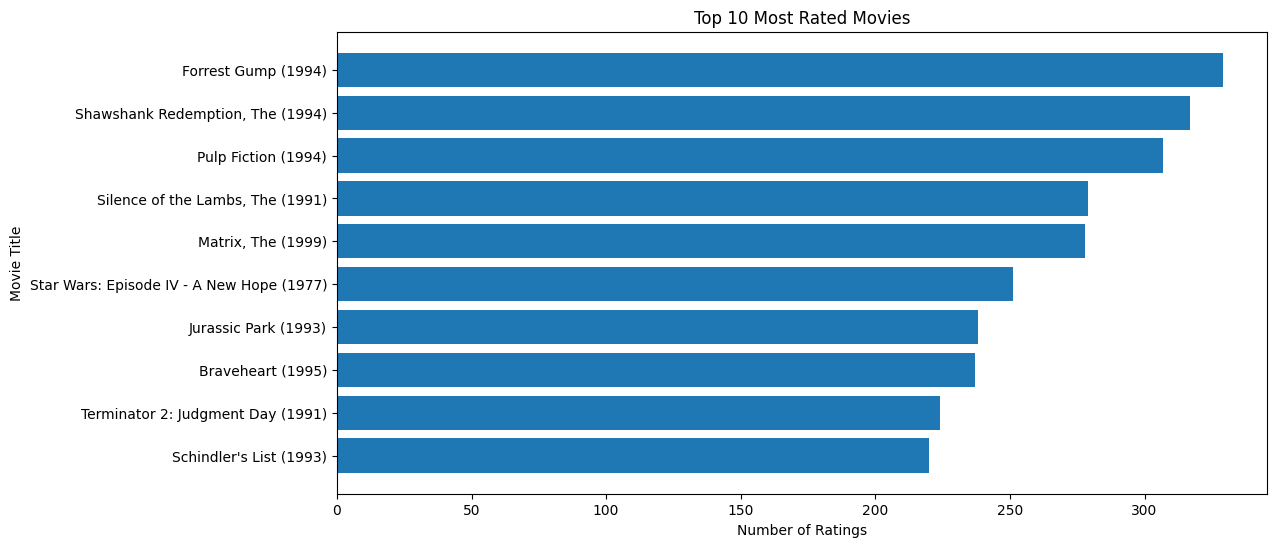

In [6]:
top_movies = movie_stats.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_movies["title"], top_movies["rating_count"])
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.title("Top 10 Most Rated Movies")
plt.gca().invert_yaxis()
plt.show()

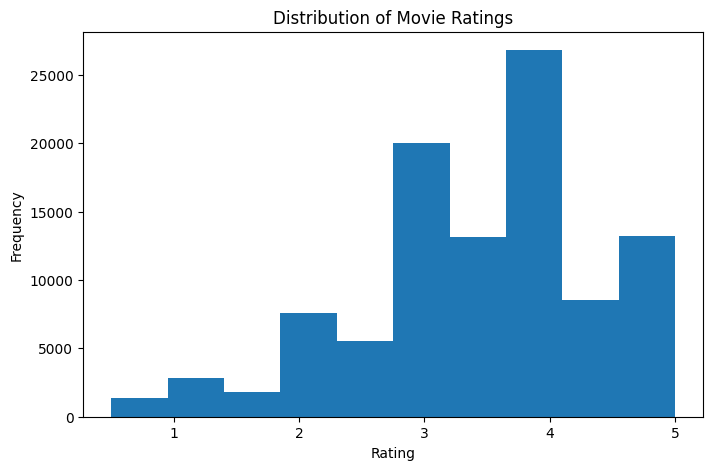

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(ratings["rating"], bins=10)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Movie Ratings")
plt.show()

In [8]:
# Create user-movie matrix
user_movie_matrix = movie_data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

# Fill missing values with 0
user_movie_matrix_filled = user_movie_matrix.fillna(0)

print("User-Movie Matrix Shape:", user_movie_matrix_filled.shape)
display(user_movie_matrix_filled.head())

User-Movie Matrix Shape: (610, 9719)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Calculate similarity between users
user_similarity = cosine_similarity(user_movie_matrix_filled)

# Convert to DataFrame
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix_filled.index,
    columns=user_movie_matrix_filled.index
)

print("User Similarity Matrix:")
display(user_similarity_df.head())

User Similarity Matrix:


userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [10]:
def recommend_movies(user_id, num_recommendations=5):
    if user_id not in user_similarity_df.index:
        return "User ID not found. Please enter a valid user ID."

    # Find similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]

    # Movies already watched by target user
    watched_movies = user_movie_matrix.loc[user_id].dropna().index.tolist()

    # Get ratings from similar users
    similar_user_ratings = user_movie_matrix.loc[similar_users.index]

    # Average ratings from similar users
    recommended_movies = similar_user_ratings.mean().sort_values(ascending=False)

    # Remove already watched movies
    recommended_movies = recommended_movies.drop(labels=watched_movies, errors="ignore")

    # Return top recommendations
    return recommended_movies.head(num_recommendations)

In [11]:
user_id = 25

recommendations = recommend_movies(user_id, 10)

print(f"Recommended Movies for User {user_id}:")
display(recommendations)

Recommended Movies for User 25:


,0
title,
21 Jump Street (2012),5.0
Braveheart (1995),5.0
"Amazing Spider-Man, The (2012)",5.0
Deadpool (2016),5.0
Edge of Tomorrow (2014),5.0
Big Hero 6 (2014),5.0
"Prestige, The (2006)",5.0
Minority Report (2002),5.0
Interstellar (2014),5.0


In [12]:
mood_genre_map = {
    "happy": ["Comedy", "Animation", "Adventure"],
    "sad": ["Drama", "Romance"],
    "stressed": ["Comedy", "Fantasy", "Family"],
    "romantic": ["Romance", "Drama"],
    "adventurous": ["Action", "Adventure", "Sci-Fi"],
    "bored": ["Thriller", "Mystery", "Crime"]
}

print("Available moods:")
for mood in mood_genre_map.keys():
    print("-", mood)

Available moods:
- happy
- sad
- stressed
- romantic
- adventurous
- bored


In [13]:
def find_movie_twin(user_id):
    if user_id not in user_similarity_df.index:
        return "User ID not found."

    twin_user = user_similarity_df[user_id].sort_values(ascending=False).index[1]
    similarity_score = user_similarity_df.loc[user_id, twin_user]

    return twin_user, round(similarity_score * 100, 2)

In [14]:
def cinemood_recommend(user_id, mood="happy", preferred_genre=None, num_recommendations=5):
    if user_id not in user_similarity_df.index:
        return "User ID not found. Please enter a valid user ID."

    mood = mood.lower()

    if mood not in mood_genre_map:
        return "Invalid mood. Choose from: happy, sad, stressed, romantic, adventurous, bored"

    # Find similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]

    # Movies already watched by target user
    watched_movies = user_movie_matrix.loc[user_id].dropna().index.tolist()

    # Ratings from similar users
    similar_user_ratings = user_movie_matrix.loc[similar_users.index]

    # Average rating from similar users
    recommendation_scores = similar_user_ratings.mean().reset_index()
    recommendation_scores.columns = ["title", "similar_user_rating"]

    # Remove already watched movies
    recommendation_scores = recommendation_scores[
        ~recommendation_scores["title"].isin(watched_movies)
    ]

    # Merge with movie details and stats
    recommendation_scores = recommendation_scores.merge(movies, on="title", how="left")
    recommendation_scores = recommendation_scores.merge(movie_stats, on="title", how="left")

    # Drop missing values
    recommendation_scores = recommendation_scores.dropna()

    # Mood filter
    mood_genres = mood_genre_map[mood]

    def matches_mood(genre_text):
        return any(genre in genre_text for genre in mood_genres)

    recommendation_scores = recommendation_scores[
        recommendation_scores["genres"].apply(matches_mood)
    ]

    # Preferred genre filter, optional
    if preferred_genre:
        recommendation_scores = recommendation_scores[
            recommendation_scores["genres"].str.contains(preferred_genre, case=False, na=False)
        ]

    if recommendation_scores.empty:
        return "No recommendations found for this mood/genre. Try another mood or remove preferred genre."

    # Normalize values for CineScore
    recommendation_scores["rating_score"] = recommendation_scores["average_rating"] / 5
    recommendation_scores["popularity_score"] = recommendation_scores["rating_count"] / recommendation_scores["rating_count"].max()
    recommendation_scores["similarity_score"] = recommendation_scores["similar_user_rating"] / 5

    # Custom CineScore formula
    recommendation_scores["CineScore"] = (
        0.50 * recommendation_scores["similarity_score"] +
        0.30 * recommendation_scores["rating_score"] +
        0.20 * recommendation_scores["popularity_score"]
    ) * 100

    recommendation_scores = recommendation_scores.sort_values(by="CineScore", ascending=False)

    final_recommendations = recommendation_scores[
        ["title", "genres", "average_rating", "rating_count", "CineScore"]
    ].head(num_recommendations)

    final_recommendations["CineScore"] = final_recommendations["CineScore"].round(2)
    final_recommendations["average_rating"] = final_recommendations["average_rating"].round(2)

    return final_recommendations

In [15]:
user_id = 25
mood = "adventurous"
preferred_genre = "Sci-Fi"

twin_user, twin_score = find_movie_twin(user_id)

print("🎬 Welcome to CineMood AI")
print("--------------------------------")
print(f"User ID: {user_id}")
print(f"Mood: {mood}")
print(f"Preferred Genre: {preferred_genre}")
print(f"Your Movie Twin: User {twin_user}")
print(f"Taste Similarity: {twin_score}%")
print("--------------------------------")

final_recs = cinemood_recommend(user_id, mood, preferred_genre, 5)

print("Top Movie Recommendations:")
display(final_recs)

🎬 Welcome to CineMood AI
--------------------------------
User ID: 25
Mood: adventurous
Preferred Genre: Sci-Fi
Your Movie Twin: User 189
Taste Similarity: 46.42%
--------------------------------
Top Movie Recommendations:


,title,genres,average_rating,rating_count,CineScore
7987,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,4.14,196,92.33
7986,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,4.22,211,89.13
5665,Minority Report (2002),Action|Crime|Mystery|Sci-Fi|Thriller,3.64,120,82.54
6758,"Prestige, The (2006)",Drama|Mystery|Sci-Fi|Thriller,4.01,90,82.07
4389,Interstellar (2014),Sci-Fi|IMAX,3.99,73,80.48


In [16]:
def explain_recommendations(recommendation_df, mood, preferred_genre=None):
    if isinstance(recommendation_df, str):
        print(recommendation_df)
        return

    print("Why these movies were recommended:")
    print("--------------------------------")

    for index, row in recommendation_df.iterrows():
        print(f"\nMovie: {row['title']}")
        print(f"CineScore: {row['CineScore']}/100")
        print("Reason:")
        print(f"- Matches your current mood: {mood}")
        print(f"- Belongs to genres: {row['genres']}")
        print(f"- Has an average rating of {row['average_rating']}/5")
        print(f"- Rated by {int(row['rating_count'])} users")

        if preferred_genre:
            print(f"- Also matches your preferred genre: {preferred_genre}")

In [17]:
explain_recommendations(final_recs, mood, preferred_genre)


Why these movies were recommended:
--------------------------------

Movie: Star Wars: Episode VI - Return of the Jedi (1983)
CineScore: 92.33/100
Reason:
- Matches your current mood: adventurous
- Belongs to genres: Action|Adventure|Sci-Fi
- Has an average rating of 4.14/5
- Rated by 196 users
- Also matches your preferred genre: Sci-Fi

Movie: Star Wars: Episode V - The Empire Strikes Back (1980)
CineScore: 89.13/100
Reason:
- Matches your current mood: adventurous
- Belongs to genres: Action|Adventure|Sci-Fi
- Has an average rating of 4.22/5
- Rated by 211 users
- Also matches your preferred genre: Sci-Fi

Movie: Minority Report (2002)
CineScore: 82.54/100
Reason:
- Matches your current mood: adventurous
- Belongs to genres: Action|Crime|Mystery|Sci-Fi|Thriller
- Has an average rating of 3.64/5
- Rated by 120 users
- Also matches your preferred genre: Sci-Fi

Movie: Prestige, The (2006)
CineScore: 82.07/100
Reason:
- Matches your current mood: adventurous
- Belongs to genres: Drama|

In [18]:
def generate_watchlist(recommendation_df):
    if isinstance(recommendation_df, str):
        print(recommendation_df)
        return

    slots = ["Friday Night", "Saturday Afternoon", "Saturday Night", "Sunday Evening", "Bonus Pick"]

    print("🍿 Your Personalized Weekend Watchlist")
    print("--------------------------------")

    for slot, movie in zip(slots, recommendation_df["title"].values):
        print(f"{slot}: {movie}")

In [19]:
generate_watchlist(final_recs)

🍿 Your Personalized Weekend Watchlist
--------------------------------
Friday Night: Star Wars: Episode VI - Return of the Jedi (1983)
Saturday Afternoon: Star Wars: Episode V - The Empire Strikes Back (1980)
Saturday Night: Minority Report (2002)
Sunday Evening: Prestige, The (2006)
Bonus Pick: Interstellar (2014)


In [20]:
def get_movie_personality(user_id):
    if user_id not in user_movie_matrix.index:
        return "User ID not found."

    watched = user_movie_matrix.loc[user_id].dropna().reset_index()
    watched.columns = ["title", "rating"]

    watched = watched.merge(movies, on="title", how="left")

    # Keep only movies rated 4 or above
    liked_movies = watched[watched["rating"] >= 4]

    if liked_movies.empty:
        return "The Casual Viewer", "You have mixed movie preferences."

    genre_list = []

    for genres in liked_movies["genres"]:
        genre_list.extend(genres.split("|"))

    top_genres = pd.Series(genre_list).value_counts().head(3)

    main_genre = top_genres.index[0]

    personality_map = {
        "Sci-Fi": ("The Sci-Fi Explorer", "You enjoy futuristic, imaginative, and technology-based stories."),
        "Action": ("The Action Hunter", "You like energetic, thrilling, and high-intensity movies."),
        "Comedy": ("The Comfort Viewer", "You enjoy light-hearted, fun, and relaxing movies."),
        "Romance": ("The Romantic Dreamer", "You enjoy emotional, relationship-focused stories."),
        "Drama": ("The Deep Thinker", "You like meaningful, emotional, and story-rich movies."),
        "Thriller": ("The Thriller Detective", "You enjoy suspense, mystery, and unexpected twists."),
        "Adventure": ("The Adventure Seeker", "You like exciting journeys and exploration-based movies."),
        "Animation": ("The Creative Soul", "You enjoy imaginative, colorful, and expressive stories."),
        "Crime": ("The Mystery Solver", "You enjoy investigation, crime, and intense storytelling.")
    }

    personality, description = personality_map.get(
        main_genre,
        ("The Balanced Viewer", "You enjoy a mix of different movie genres.")
    )

    return personality, description

In [21]:
personality, personality_desc = get_movie_personality(25)

print("Your Movie Personality:")
print(personality)
print(personality_desc)

Your Movie Personality:
The Action Hunter
You like energetic, thrilling, and high-intensity movies.


In [22]:
def cold_start_recommendation(mood="happy", preferred_genre=None, num_recommendations=5):
    mood = mood.lower()

    if mood not in mood_genre_map:
        return "Invalid mood. Choose from: happy, sad, stressed, romantic, adventurous, bored"

    mood_genres = mood_genre_map[mood]

    # Merge movie stats with movie details
    popular_movies = movie_stats.merge(movies, on="title", how="left")

    # Filter by mood genres
    def matches_mood(genre_text):
        return any(genre in genre_text for genre in mood_genres)

    popular_movies = popular_movies[
        popular_movies["genres"].apply(matches_mood)
    ]

    # Optional preferred genre filter
    if preferred_genre:
        popular_movies = popular_movies[
            popular_movies["genres"].str.contains(preferred_genrier if False else preferred_genre, case=False, na=False)
        ]

    # Avoid movies with very few ratings
    popular_movies = popular_movies[popular_movies["rating_count"] >= 50]

    if popular_movies.empty:
        return "No cold-start recommendations found. Try another mood or genre."

    popular_movies["ColdStartScore"] = (
        0.60 * (popular_movies["average_rating"] / 5) +
        0.40 * (popular_movies["rating_count"] / popular_movies["rating_count"].max())
    ) * 100

    popular_movies = popular_movies.sort_values(by="ColdStartScore", ascending=False)

    result = popular_movies[
        ["title", "genres", "average_rating", "rating_count", "ColdStartScore"]
    ].head(num_recommendations)

    result["average_rating"] = result["average_rating"].round(2)
    result["ColdStartScore"] = result["ColdStartScore"].round(2)

    return result

In [23]:
new_user_recs = cold_start_recommendation(
    mood="happy",
    preferred_genre="Comedy",
    num_recommendations=5
)

print("Cold-Start Recommendations for New User:")
display(new_user_recs)

Cold-Start Recommendations for New User:


,title,genres,average_rating,rating_count,ColdStartScore
0,Forrest Gump (1994),Comedy|Drama|Romance|War,4.16,329,89.97
2,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.20,307,87.69
11,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.92,215,73.19
28,Fargo (1996),Comedy|Crime|Drama|Thriller,4.12,181,71.40
33,Back to the Future (1985),Adventure|Comedy|Sci-Fi,4.04,171,69.25


In [24]:
def advanced_cinemood_ai(user_id=None, mood="happy", preferred_genre=None, num_recommendations=5):
    print("🎬 CineMood AI - Advanced Movie Recommendation System")
    print("=" * 60)

    print(f"Mood Selected: {mood}")
    print(f"Preferred Genre: {preferred_genre if preferred_genre else 'Not specified'}")
    print("=" * 60)

    # If user is new or invalid, use cold-start recommendation
    if user_id is None or user_id not in user_similarity_df.index:
        print("New user detected. Using cold-start recommendation based on mood, genre, and popularity.")
        recommendations = cold_start_recommendation(mood, preferred_genre, num_recommendations)

        if isinstance(recommendations, str):
            print(recommendations)
            return recommendations

        display(recommendations)
        return recommendations

    # Existing user flow
    personality, personality_desc = get_movie_personality(user_id)
    twin_user, twin_score = find_movie_twin(user_id)

    print(f"User ID: {user_id}")
    print(f"Movie Personality: {personality}")
    print(f"Personality Insight: {personality_desc}")
    print(f"Movie Twin: User {twin_user}")
    print(f"Taste Similarity: {twin_score}%")
    print("=" * 60)

    recommendations = cinemood_recommend(
        user_id=user_id,
        mood=mood,
        preferred_genre=preferred_genre,
        num_recommendations=num_recommendations
    )

    if isinstance(recommendations, str):
        print(recommendations)
        return recommendations

    print("Top Advanced Recommendations:")
    display(recommendations)

    explain_recommendations(recommendations, mood, preferred_genre)

    print("\n")
    generate_watchlist(recommendations)

    return recommendations

In [25]:
advanced_recs = advanced_cinemood_ai(
    user_id=25,
    mood="adventurous",
    preferred_genre="Sci-Fi",
    num_recommendations=5
)

🎬 CineMood AI - Advanced Movie Recommendation System
Mood Selected: adventurous
Preferred Genre: Sci-Fi
User ID: 25
Movie Personality: The Action Hunter
Personality Insight: You like energetic, thrilling, and high-intensity movies.
Movie Twin: User 189
Taste Similarity: 46.42%
Top Advanced Recommendations:


,title,genres,average_rating,rating_count,CineScore
7987,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,4.14,196,92.33
7986,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,4.22,211,89.13
5665,Minority Report (2002),Action|Crime|Mystery|Sci-Fi|Thriller,3.64,120,82.54
6758,"Prestige, The (2006)",Drama|Mystery|Sci-Fi|Thriller,4.01,90,82.07
4389,Interstellar (2014),Sci-Fi|IMAX,3.99,73,80.48


Why these movies were recommended:
--------------------------------

Movie: Star Wars: Episode VI - Return of the Jedi (1983)
CineScore: 92.33/100
Reason:
- Matches your current mood: adventurous
- Belongs to genres: Action|Adventure|Sci-Fi
- Has an average rating of 4.14/5
- Rated by 196 users
- Also matches your preferred genre: Sci-Fi

Movie: Star Wars: Episode V - The Empire Strikes Back (1980)
CineScore: 89.13/100
Reason:
- Matches your current mood: adventurous
- Belongs to genres: Action|Adventure|Sci-Fi
- Has an average rating of 4.22/5
- Rated by 211 users
- Also matches your preferred genre: Sci-Fi

Movie: Minority Report (2002)
CineScore: 82.54/100
Reason:
- Matches your current mood: adventurous
- Belongs to genres: Action|Crime|Mystery|Sci-Fi|Thriller
- Has an average rating of 3.64/5
- Rated by 120 users
- Also matches your preferred genre: Sci-Fi

Movie: Prestige, The (2006)
CineScore: 82.07/100
Reason:
- Matches your current mood: adventurous
- Belongs to genres: Drama|

In [26]:
new_user_advanced_recs = advanced_cinemood_ai(
    user_id=None,
    mood="romantic",
    preferred_genre="Romance",
    num_recommendations=5
)

🎬 CineMood AI - Advanced Movie Recommendation System
Mood Selected: romantic
Preferred Genre: Romance
New user detected. Using cold-start recommendation based on mood, genre, and popularity.


,title,genres,average_rating,rating_count,ColdStartScore
0,Forrest Gump (1994),Comedy|Drama|Romance|War,4.16,329,89.97
14,American Beauty (1999),Drama|Romance,4.06,204,73.48
52,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,4.23,142,68.05
35,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,3.87,170,67.08
54,Good Will Hunting (1997),Drama|Romance,4.08,141,66.08


In [27]:
def plot_cinescore_chart(recommendation_df):
    if isinstance(recommendation_df, str):
        print(recommendation_df)
        return

    score_column = "CineScore" if "CineScore" in recommendation_df.columns else "ColdStartScore"

    plt.figure(figsize=(12, 6))
    plt.barh(recommendation_df["title"], recommendation_df[score_column])
    plt.xlabel(score_column)
    plt.ylabel("Movie Title")
    plt.title("Recommended Movies Score Comparison")
    plt.gca().invert_yaxis()
    plt.show()

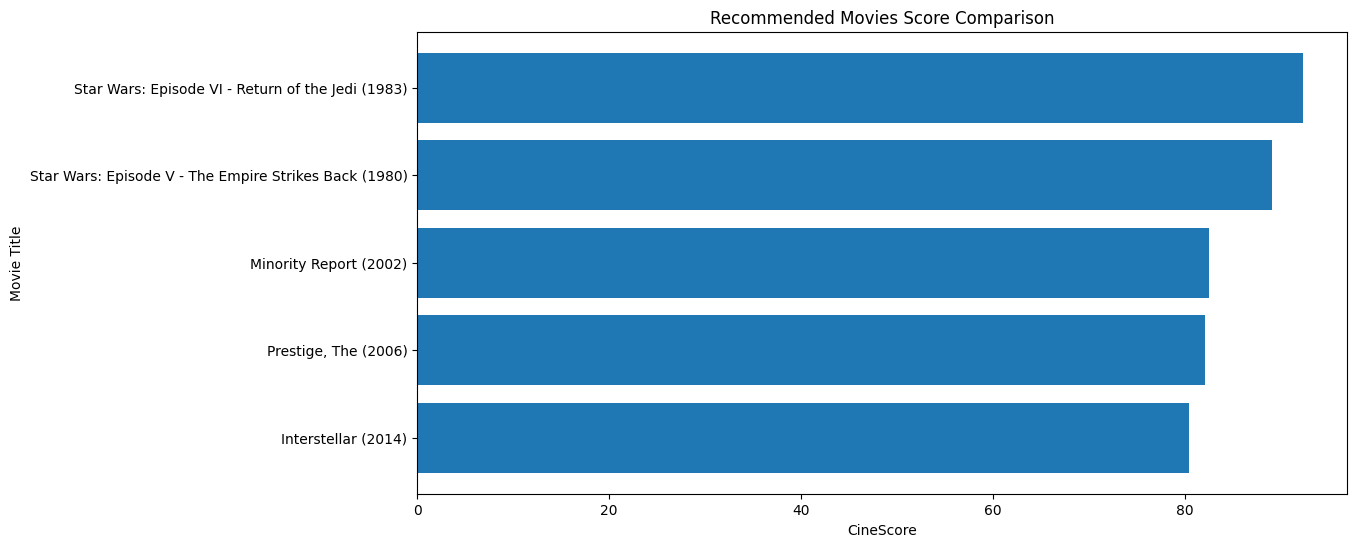

In [28]:
plot_cinescore_chart(advanced_recs)

In [29]:
advanced_recs.to_csv("cinemood_ai_recommendations.csv", index=False)

print("Recommendations exported successfully as cinemood_ai_recommendations.csv")

Recommendations exported successfully as cinemood_ai_recommendations.csv


In [30]:
from google.colab import files
files.download("cinemood_ai_recommendations.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
print("Final Project Summary")
print("=" * 60)
print("Project Name: CineMood AI")
print("Project Type: AI-Based Movie Recommendation System")
print("Dataset Used: MovieLens Latest Small Dataset")
print("Algorithm Used: Collaborative Filtering with Cosine Similarity")
print("Advanced Features:")
print("1. Mood-based movie recommendation")
print("2. User-based collaborative filtering")
print("3. Movie Twin feature")
print("4. CineScore ranking system")
print("5. Explainable recommendation reasons")
print("6. Movie personality detection")
print("7. Cold-start recommendation for new users")
print("8. Weekend watchlist generator")
print("9. Data visualizations and trend analysis")
print("=" * 60)
print("Project completed successfully.")

Final Project Summary
Project Name: CineMood AI
Project Type: AI-Based Movie Recommendation System
Dataset Used: MovieLens Latest Small Dataset
Algorithm Used: Collaborative Filtering with Cosine Similarity
Advanced Features:
1. Mood-based movie recommendation
2. User-based collaborative filtering
3. Movie Twin feature
4. CineScore ranking system
5. Explainable recommendation reasons
6. Movie personality detection
7. Cold-start recommendation for new users
8. Weekend watchlist generator
9. Data visualizations and trend analysis
Project completed successfully.


In [32]:
!pip install gradio

In [33]:
import gradio as gr

def cinemood_interface(user_id, mood, preferred_genre, num_recommendations):
    try:
        user_id = int(user_id)
    except:
        user_id = None

    if preferred_genre == "None":
        preferred_genre = None

    output = ""

    output += "🎬 CineMood AI - Movie Recommendation System\n"
    output += "=" * 55 + "\n\n"
    output += f"Selected Mood: {mood}\n"
    output += f"Preferred Genre: {preferred_genre if preferred_genre else 'Not specified'}\n\n"

    if user_id is None or user_id not in user_similarity_df.index:
        output += "New user detected. Using cold-start recommendation.\n\n"

        recommendations = cold_start_recommendation(
            mood=mood,
            preferred_genre=preferred_genre,
            num_recommendations=num_recommendations
        )

        if isinstance(recommendations, str):
            return recommendations

        output += "Top Recommendations:\n\n"

        for i, row in recommendations.iterrows():
            output += f"🎥 {row['title']}\n"
            output += f"Genres: {row['genres']}\n"
            output += f"Average Rating: {row['average_rating']}/5\n"
            output += f"Rating Count: {int(row['rating_count'])}\n"
            output += f"ColdStartScore: {row['ColdStartScore']}/100\n"
            output += "-" * 45 + "\n"

        return output

    personality, personality_desc = get_movie_personality(user_id)
    twin_user, twin_score = find_movie_twin(user_id)

    output += f"User ID: {user_id}\n"
    output += f"Movie Personality: {personality}\n"
    output += f"Personality Insight: {personality_desc}\n"
    output += f"Movie Twin: User {twin_user}\n"
    output += f"Taste Similarity: {twin_score}%\n\n"

    recommendations = cinemood_recommend(
        user_id=user_id,
        mood=mood,
        preferred_genre=preferred_genre,
        num_recommendations=num_recommendations
    )

    if isinstance(recommendations, str):
        return recommendations

    output += "Top Recommendations:\n\n"

    for i, row in recommendations.iterrows():
        output += f"🎥 {row['title']}\n"
        output += f"Genres: {row['genres']}\n"
        output += f"Average Rating: {row['average_rating']}/5\n"
        output += f"Rating Count: {int(row['rating_count'])}\n"
        output += f"CineScore: {row['CineScore']}/100\n"
        output += "Why recommended:\n"
        output += f"- Matches your mood: {mood}\n"
        output += f"- Matches genre pattern: {row['genres']}\n"
        output += "- Recommended using similar users' ratings\n"

        if preferred_genre:
            output += f"- Matches preferred genre: {preferred_genre}\n"

        output += "-" * 45 + "\n"

    output += "\n🍿 Weekend Watchlist:\n"
    slots = ["Friday Night", "Saturday Afternoon", "Saturday Night", "Sunday Evening", "Bonus Pick"]

    for slot, movie in zip(slots, recommendations["title"].values):
        output += f"{slot}: {movie}\n"

    return output

In [34]:
mood_options = ["happy", "sad", "stressed", "romantic", "adventurous", "bored"]

genre_options = [
    "None", "Action", "Adventure", "Animation", "Comedy", "Crime",
    "Drama", "Fantasy", "Mystery", "Romance", "Sci-Fi", "Thriller"
]

interface = gr.Interface(
    fn=cinemood_interface,
    inputs=[
        gr.Textbox(label="Enter User ID", value="25"),
        gr.Dropdown(choices=mood_options, label="Select Your Mood", value="adventurous"),
        gr.Dropdown(choices=genre_options, label="Preferred Genre", value="Sci-Fi"),
        gr.Slider(minimum=3, maximum=10, value=5, step=1, label="Number of Recommendations")
    ],
    outputs=gr.Textbox(label="CineMood AI Recommendations", lines=25),
    title="🎬 CineMood AI",
    description="A personalized movie recommendation system based on user ratings, mood, genre preference, collaborative filtering, and CineScore ranking."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d03466799093fe1143.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [35]:
import gradio as gr

custom_css = """
body {
    background: linear-gradient(135deg, #0f172a, #111827);
}

.gradio-container {
    font-family: 'Inter', sans-serif;
}

#main-title {
    text-align: center;
    padding: 25px;
    border-radius: 18px;
    background: linear-gradient(135deg, #111827, #1e293b);
    color: white;
    box-shadow: 0px 8px 25px rgba(0,0,0,0.25);
}

#main-title h1 {
    font-size: 42px;
    margin-bottom: 8px;
}

#main-title p {
    font-size: 16px;
    color: #cbd5e1;
}

.output-box textarea {
    font-size: 15px !important;
    line-height: 1.6 !important;
}

.stat-card {
    padding: 18px;
    border-radius: 16px;
    background: #111827;
    color: white;
    border: 1px solid #334155;
    text-align: center;
}

.footer {
    text-align: center;
    color: #94a3b8;
    padding: 15px;
}
"""

In [36]:
def cinemood_interface_pretty(user_id, mood, preferred_genre, num_recommendations):
    try:
        user_id = int(user_id)
    except:
        user_id = None

    if preferred_genre == "None":
        preferred_genre = None

    header = """
🎬 CINE MOOD AI RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

    output = header
    output += f"\n🧠 Selected Mood: {mood.capitalize()}"
    output += f"\n🎭 Preferred Genre: {preferred_genre if preferred_genre else 'Not specified'}"
    output += f"\n🎯 Number of Recommendations: {num_recommendations}"
    output += "\n\n"

    # New user / cold-start case
    if user_id is None or user_id not in user_similarity_df.index:
        output += "✨ New User Mode Activated\n"
        output += "Since no valid user history was found, recommendations are based on mood, genre, popularity, and rating trends.\n\n"

        recommendations = cold_start_recommendation(
            mood=mood,
            preferred_genre=preferred_genre,
            num_recommendations=num_recommendations
        )

        if isinstance(recommendations, str):
            return recommendations, None

        output += "🍿 TOP MOVIE PICKS FOR YOU\n"
        output += "━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"

        for rank, (_, row) in enumerate(recommendations.iterrows(), start=1):
            output += f"{rank}. 🎥 {row['title']}\n"
            output += f"   🎬 Genres: {row['genres']}\n"
            output += f"   ⭐ Average Rating: {row['average_rating']}/5\n"
            output += f"   👥 Rating Count: {int(row['rating_count'])}\n"
            output += f"   🔥 ColdStartScore: {row['ColdStartScore']}/100\n"
            output += f"   💡 Why: This movie matches your {mood} mood and has strong popularity/rating performance.\n\n"

        watchlist = "\n🍿 WEEKEND WATCHLIST\n"
        watchlist += "━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
        slots = ["Friday Night", "Saturday Afternoon", "Saturday Night", "Sunday Evening", "Bonus Pick"]

        for slot, movie in zip(slots, recommendations["title"].values):
            watchlist += f"{slot}: {movie}\n"

        output += watchlist

        return output, recommendations

    # Existing user case
    personality, personality_desc = get_movie_personality(user_id)
    twin_user, twin_score = find_movie_twin(user_id)

    output += "👤 USER TASTE PROFILE\n"
    output += "━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
    output += f"User ID: {user_id}\n"
    output += f"Movie Personality: {personality}\n"
    output += f"Insight: {personality_desc}\n"
    output += f"Movie Twin: User {twin_user}\n"
    output += f"Taste Similarity: {twin_score}%\n\n"

    recommendations = cinemood_recommend(
        user_id=user_id,
        mood=mood,
        preferred_genre=preferred_genre,
        num_recommendations=num_recommendations
    )

    if isinstance(recommendations, str):
        return recommendations, None

    output += "🍿 PERSONALIZED RECOMMENDATIONS\n"
    output += "━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"

    for rank, (_, row) in enumerate(recommendations.iterrows(), start=1):
        output += f"{rank}. 🎥 {row['title']}\n"
        output += f"   🎬 Genres: {row['genres']}\n"
        output += f"   ⭐ Average Rating: {row['average_rating']}/5\n"
        output += f"   👥 Rated by: {int(row['rating_count'])} users\n"
        output += f"   🔥 CineScore: {row['CineScore']}/100\n"
        output += "   💡 Why recommended:\n"
        output += f"      - Matches your {mood} mood\n"
        output += f"      - Recommended using similar users' ratings\n"
        output += f"      - Strong rating and popularity performance\n"

        if preferred_genre:
            output += f"      - Matches your preferred genre: {preferred_genre}\n"

        output += "\n"

    output += "🍿 WEEKEND WATCHLIST\n"
    output += "━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"

    slots = ["Friday Night", "Saturday Afternoon", "Saturday Night", "Sunday Evening", "Bonus Pick"]

    for slot, movie in zip(slots, recommendations["title"].values):
        output += f"{slot}: {movie}\n"

    return output, recommendations

In [37]:
mood_options = ["happy", "sad", "stressed", "romantic", "adventurous", "bored"]

genre_options = [
    "None", "Action", "Adventure", "Animation", "Comedy", "Crime",
    "Drama", "Fantasy", "Mystery", "Romance", "Sci-Fi", "Thriller"
]

with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:

    gr.HTML(
        """
        <div id="main-title">
            <h1>🎬 CineMood AI</h1>
            <p>Personalized Movie Recommendation System based on Mood, Genre, Ratings & AI Similarity</p>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("## 🎯 Choose Your Movie Mood")

            user_id_input = gr.Textbox(
                label="User ID",
                value="25",
                placeholder="Enter MovieLens User ID, example: 25"
            )

            mood_input = gr.Dropdown(
                choices=mood_options,
                label="Current Mood",
                value="adventurous"
            )

            genre_input = gr.Dropdown(
                choices=genre_options,
                label="Preferred Genre",
                value="Sci-Fi"
            )

            num_input = gr.Slider(
                minimum=3,
                maximum=10,
                value=5,
                step=1,
                label="Number of Recommendations"
            )

            recommend_btn = gr.Button("✨ Generate Recommendations", variant="primary")
            clear_btn = gr.Button("Clear")

        with gr.Column(scale=2):
            gr.Markdown("## 🍿 Your AI Movie Picks")

            output_text = gr.Textbox(
                label="CineMood AI Output",
                lines=28,
                elem_classes="output-box"
            )

            output_table = gr.Dataframe(
                label="Recommendation Table",
                interactive=False
            )

    gr.Markdown("## 🧪 Try Example Inputs")

    gr.Examples(
        examples=[
            ["25", "adventurous", "Sci-Fi", 5],
            ["42", "happy", "Comedy", 5],
            ["100", "romantic", "Romance", 5],
            ["", "stressed", "Comedy", 5],
            ["99999", "bored", "Thriller", 5]
        ],
        inputs=[user_id_input, mood_input, genre_input, num_input]
    )

    gr.HTML(
        """
        <div class="footer">
            Built using Python, Pandas, Scikit-learn, Collaborative Filtering, Cosine Similarity and Gradio.
        </div>
        """
    )

    recommend_btn.click(
        fn=cinemood_interface_pretty,
        inputs=[user_id_input, mood_input, genre_input, num_input],
        outputs=[output_text, output_table]
    )

    clear_btn.click(
        fn=lambda: ("", None),
        inputs=[],
        outputs=[output_text, output_table]
    )

demo.launch(share=True)

/tmp/ipykernel_2522/1585986920.py:8: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_2522/1585986920.py:8: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7c1718d1c2c8d6a8b5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
